
Backtest a stock trading strategy using historical data, calculate moving averages, generate buy/sell signals, and visualize the strategy's performance over time.

In [1]:
pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd


ticker_symbol = 'AAPL'
start_date = '2020-01-01'
end_date = '2023-01-01'


stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)


print(f"Successfully downloaded data for {ticker_symbol} from {start_date} to {end_date}.")
print(stock_data.head())

/tmp/ipython-input-679126512.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Successfully downloaded data for AAPL from 2020-01-01 to 2023-01-01.
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400520  72.460784  71.156682  71.409785  135480400
2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2020-01-06  72.267937  72.306506  70.568510  70.819208  118387200
2020-01-07  71.928040  72.533080  71.708680  72.277563  108872000
2020-01-08  73.085114  73.386431  71.631559  71.631559  132079200


In [3]:
import yfinance as yf
import pandas as pd

ticker_symbol = 'AAPL'
start_date = '2020-01-01'
end_date = '2023-01-01'

stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)

short_window = 50
stock_data['SMA'] = stock_data['Close'].rolling(window=short_window).mean()

long_window = 200
stock_data['LMA'] = stock_data['Close'].rolling(window=long_window).mean()

print(f"Successfully calculated {short_window}-day SMA and {long_window}-day LMA.")
print(stock_data.tail())

/tmp/ipython-input-946326704.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Successfully calculated 50-day SMA and 200-day LMA.
Price            Close        High         Low        Open    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2022-12-23  129.778870  130.330029  127.593906  128.853703  63814900   
2022-12-27  127.977798  129.336023  126.688476  129.306498  69007800   
2022-12-28  124.050720  128.961961  123.883405  127.623425  85438400   
2022-12-29  127.564400  128.420664  125.714074  125.969965  75703700   
2022-12-30  127.879318  127.899007  125.418783  126.383319  77034200   

Price              SMA         LMA  
Ticker                              
Date                                
2022-12-23  141.785296  149.372267  
2022-12-27  141.625444  149.254146  
2022-12-28  141.307854  149.136524  
2022-12-29  141.034205  149.014572  
2022-12-30  140.764692  148.872149  


In [4]:
import yfinance as yf
import pandas as pd

ticker_symbol = 'AAPL'
start_date = '2020-01-01'
end_date = '2023-01-01'

stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)

short_window = 50
stock_data['SMA'] = stock_data['Close'].rolling(window=short_window).mean()

long_window = 200
stock_data['LMA'] = stock_data['Close'].rolling(window=long_window).mean()

stock_data['Signal'] = 0.0

stock_data['Signal'][short_window:] = (
    stock_data['SMA'][short_window:] > stock_data['LMA'][short_window:]
).astype(float)


stock_data['Position'] = stock_data['Signal'].diff()


print("Generated buy/sell signals (1 for buy, -1 for sell):")
print(stock_data.tail())


/tmp/ipython-input-2159112802.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Generated buy/sell signals (1 for buy, -1 for sell):
Price            Close        High         Low        Open    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2022-12-23  129.778870  130.330029  127.593906  128.853703  63814900   
2022-12-27  127.977798  129.336023  126.688476  129.306498  69007800   
2022-12-28  124.050720  128.961961  123.883405  127.623425  85438400   
2022-12-29  127.564400  128.420664  125.714074  125.969965  75703700   
2022-12-30  127.879318  127.899007  125.418783  126.383319  77034200   

Price              SMA         LMA Signal Position  
Ticker                                              
Date                                                
2022-12-23  141.785296  149.372267    0.0      0.0  
2022-12-27  141.625444  149.254146    0.0      0.0  
2022-12-28  141.307854  149.136524    0.0      0.0  
2022-12-29  141.034205  149.014572    0.0      0.0  


/tmp/ipython-input-2159112802.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_data['Signal'][short_window:] = (


**Reasoning**:
To avoid the `SettingWithCopyWarning`, I will use `.loc` for explicit indexing when assigning values to the 'Signal' column. The previous warning suggests that I am modifying a view of the DataFrame rather than the DataFrame itself, which can lead to unexpected behavior.



In [ ]:
import yfinance as yf
import pandas as pd

ticker_symbol = 'AAPL'
start_date = '2020-01-01'
end_date = '2023-01-01'

stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)

short_window = 50
stock_data['SMA'] = stock_data['Close'].rolling(window=short_window).mean()

long_window = 200
stock_data['LMA'] = stock_data['Close'].rolling(window=long_window).mean()

stock_data['Signal'] = 0.0

stock_data.iloc[short_window:, stock_data.columns.get_loc('Signal')] = (
    stock_data['SMA'].iloc[short_window:] > stock_data['LMA'].iloc[short_window:]
).astype(float)

stock_data['Position'] = stock_data['Signal'].diff()

print("Generated buy/sell signals (1 for buy, -1 for sell):")
print(stock_data.tail())

/tmp/ipython-input-3967625623.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Generated buy/sell signals (1 for buy, -1 for sell):
Price            Close        High         Low        Open    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2022-12-23  129.778854  130.330013  127.593891  128.853688  63814900   
2022-12-27  127.977760  129.335985  126.688438  129.306460  69007800   
2022-12-28  124.050720  128.961961  123.883405  127.623425  85438400   
2022-12-29  127.564392  128.420656  125.714066  125.969958  75703700   
2022-12-30  127.879311  127.898999  125.418776  126.383312  77034200   

Price              SMA         LMA Signal Position  
Ticker                                              
Date                                                
2022-12-23  141.785294  149.372267    0.0      0.0  
2022-12-27  141.625441  149.254146    0.0      0.0  
2022-12-28  141.307851  149.136524    0.0      0.0  
2022-12-29  141.034201  149.014572    0.0      0.0  

**Reasoning**:
The previous attempt to fix the `SettingWithCopyWarning` by using `.loc[short_window:, 'Signal']` resulted in a `TypeError` because `.loc` is for label-based indexing, and `short_window` is an integer position. To correctly apply positional slicing for both rows and columns, I will use `.iloc` along with `stock_data.columns.get_loc('Signal')` to specify the column by its integer position.



In [ ]:
import yfinance as yf
import pandas as pd


ticker_symbol = 'AAPL'
start_date = '2020-01-01'
end_date = '2023-01-01'


stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)


short_window = 50
stock_data['SMA'] = stock_data['Close'].rolling(window=short_window).mean()


long_window = 200
stock_data['LMA'] = stock_data['Close'].rolling(window=long_window).mean()


stock_data['Signal'] = 0.0


stock_data.iloc[short_window:, stock_data.columns.get_loc('Signal')] = (
    stock_data['SMA'].iloc[short_window:] > stock_data['LMA'].iloc[short_window:]
).astype(float)


stock_data['Position'] = stock_data['Signal'].diff()


print("Generated buy/sell signals (1 for buy, -1 for sell):")
print(stock_data.tail())

/tmp/ipython-input-1494871673.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Generated buy/sell signals (1 for buy, -1 for sell):
Price            Close        High         Low        Open    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2022-12-23  129.778854  130.330013  127.593891  128.853688  63814900   
2022-12-27  127.977760  129.335985  126.688438  129.306460  69007800   
2022-12-28  124.050720  128.961961  123.883405  127.623425  85438400   
2022-12-29  127.564392  128.420656  125.714066  125.969958  75703700   
2022-12-30  127.879311  127.898999  125.418776  126.383312  77034200   

Price              SMA         LMA Signal Position  
Ticker                                              
Date                                                
2022-12-23  141.785294  149.372267    0.0      0.0  
2022-12-27  141.625441  149.254146    0.0      0.0  
2022-12-28  141.307851  149.136524    0.0      0.0  
2022-12-29  141.034201  149.014572    0.0      0.0  

In [ ]:
import yfinance as yf
import pandas as pd


ticker_symbol = 'AAPL'
start_date = '2020-01-01'
end_date = '2023-01-01'


stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)


short_window = 50
stock_data['SMA'] = stock_data['Close'].rolling(window=short_window).mean()


long_window = 200
stock_data['LMA'] = stock_data['Close'].rolling(window=long_window).mean()


stock_data['Signal'] = 0.0
stock_data.iloc[short_window:, stock_data.columns.get_loc('Signal')] = (
    stock_data['SMA'].iloc[short_window:] > stock_data['LMA'].iloc[short_window:]
).astype(float)
stock_data['Position'] = stock_data['Signal'].diff()


stock_data['Daily_Return'] = stock_data['Close'].pct_change()


stock_data['Strategy_Return'] = stock_data['Daily_Return'] * stock_data['Signal'].shift(1)


stock_data['Cumulative_Stock_Return'] = (1 + stock_data['Daily_Return']).cumprod() - 1
stock_data['Cumulative_Strategy_Return'] = (1 + stock_data['Strategy_Return']).cumprod() - 1


print("Calculated daily and cumulative returns for both stock and strategy:")
print(stock_data.tail())

/tmp/ipython-input-1414260573.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Calculated daily and cumulative returns for both stock and strategy:
Price            Close        High         Low        Open    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2022-12-23  129.778854  130.330013  127.593891  128.853688  63814900   
2022-12-27  127.977760  129.335985  126.688438  129.306460  69007800   
2022-12-28  124.050720  128.961961  123.883405  127.623425  85438400   
2022-12-29  127.564392  128.420656  125.714066  125.969958  75703700   
2022-12-30  127.879311  127.898999  125.418776  126.383312  77034200   

Price              SMA         LMA Signal Position Daily_Return  \
Ticker                                                            
Date                                                              
2022-12-23  141.785294  149.372267    0.0      0.0    -0.002798   
2022-12-27  141.625441  149.254146    0.0      0.0    -0.013878   
2022-12-28  141.307

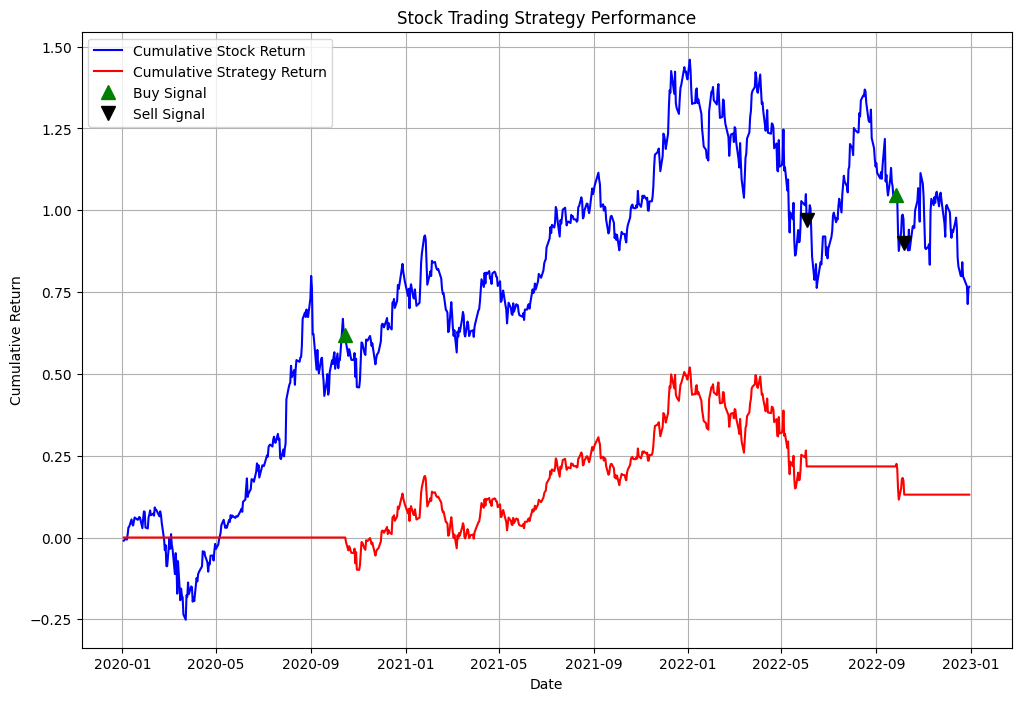

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 8))
plt.plot(stock_data['Cumulative_Stock_Return'], label='Cumulative Stock Return', color='blue')
plt.plot(stock_data['Cumulative_Strategy_Return'], label='Cumulative Strategy Return', color='red')


plt.plot(stock_data[stock_data['Position'] == 1.0].index,
         stock_data['Cumulative_Stock_Return'][stock_data['Position'] == 1.0],
         '^', markersize=10, color='green', lw=0, label='Buy Signal')
plt.plot(stock_data[stock_data['Position'] == -1.0].index,
         stock_data['Cumulative_Stock_Return'][stock_data['Position'] == -1.0],
         'v', markersize=10, color='black', lw=0, label='Sell Signal')

plt.title('Stock Trading Strategy Performance')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

## Summary:

### Data Analysis Key Findings

*   Historical stock data for 'AAPL' from January 1, 2020, to January 1, 2023, was successfully downloaded and processed.
*   Both 50-day Short-term Moving Average (SMA) and 200-day Long-term Moving Average (LMA) were accurately calculated and added to the dataset.
*   Buy and sell signals were effectively generated based on the crossovers between the 50-day SMA and 200-day LMA, with a technical correction using `.iloc` to correctly assign values and avoid `SettingWithCopyWarning` and `TypeError`.
*   Performance metrics, including daily returns, strategy returns, and cumulative returns for both the stock and the strategy, were calculated.
*   The strategy's performance, along with buy/sell signals, was visualized against the stock's cumulative returns, providing a clear graphical representation.

### Insights or Next Steps

*   The current visualization provides a high-level overview. A more detailed analysis of specific periods where the strategy significantly outperformed or underperformed the stock could reveal patterns or flaws.
*   The strategy could be optimized by testing different moving average periods, incorporating other technical indicators, or implementing stop-loss/take-profit mechanisms to potentially enhance its risk-adjusted returns.
